# May 18 Final Checkpoint Report

## Economic Spillover Effects of Wars on Neighboring and Non-Neighbor Host Countries

This notebook consolidates the current project into a final checkpoint format for the May 18 stage. It does not replace the data collection and machine learning notebooks. Instead, it summarizes the research question, dataset, exploratory results, hypothesis tests, machine learning results, limitations, and ethics.

**Main research question:** Do wars create measurable economic spillover effects on neighboring and major host countries, especially through refugee exposure and macroeconomic changes?

## 1. Project Scope

The project analyzes two conflict cases:

1. Syrian Civil War
2. Russia–Ukraine War

For each conflict, the dataset compares neighboring host countries with non-neighbor major host countries. The unit of observation is a host-country-year.

The analysis is exploratory. The results show associations and patterns, not causal effects.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, mannwhitneyu

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

cwd = Path.cwd()
possible_roots = [cwd, cwd.parent]
REPO_ROOT = None
for root in possible_roots:
    if (root / 'data' / 'processed' / 'conflict_host_panel_2010_2024.csv').exists():
        REPO_ROOT = root
        break
if REPO_ROOT is None:
    REPO_ROOT = cwd

DATA_PATH = REPO_ROOT / 'data' / 'processed' / 'conflict_host_panel_2010_2024.csv'
FIGURE_DIR = REPO_ROOT / 'outputs' / 'figures'
TABLE_DIR = REPO_ROOT / 'outputs' / 'tables'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print('Detected repo root:', REPO_ROOT)
print('Data path:', DATA_PATH)
print('Data exists:', DATA_PATH.exists())

Detected repo root: /Users/barisozerdem/Documents/GitHub/DSA210-TermProject
Data path: /Users/barisozerdem/Documents/GitHub/DSA210-TermProject/data/processed/conflict_host_panel_2010_2024.csv
Data exists: True


## 2. Dataset Overview

The final dataset combines:

- conflict timing and intensity,
- refugee and asylum-seeker exposure,
- World Bank macroeconomic indicators,
- host-country grouping information.

The main processed file used in this checkpoint is `data/processed/conflict_host_panel_2010_2024.csv`.

In [2]:
df = pd.read_csv(DATA_PATH)

print('Dataset shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nYear range:', int(df['year'].min()), '-', int(df['year'].max()))
print('\nRows by conflict case:')
print(df['conflict_case'].value_counts())
print('\nRows by host group:')
print(df.groupby(['conflict_case', 'host_group']).size())

df.head()

Dataset shape: (330, 19)

Columns:
['conflict_case', 'origin_name', 'origin_iso', 'host_name', 'host_iso', 'host_group', 'year', 'post_conflict', 'conflict_intensity', 'refugee_stock', 'asylum_seekers', 'host_population', 'refugees_per_1000', 'log_refugee_stock', 'gdp_growth', 'inflation', 'unemployment', 'trade_pct_gdp', 'current_account_pct_gdp']

Year range: 2010 - 2024

Rows by conflict case:
conflict_case
Russia-Ukraine War    195
Syrian Civil War      135
Name: count, dtype: int64

Rows by host group:
conflict_case       host_group                
Russia-Ukraine War  neighboring_host               75
                    non_neighbor_european_host    120
Syrian Civil War    neighboring_host               60
                    non_neighbor_european_host     60
                    regional_non_neighbor_host     15
dtype: int64


,conflict_case,origin_name,origin_iso,host_name,host_iso,host_group,year,post_conflict,conflict_intensity,refugee_stock,asylum_seekers,host_population,refugees_per_1000,log_refugee_stock,gdp_growth,inflation,unemployment,trade_pct_gdp,current_account_pct_gdp
0,Syrian Civil War,Syria,SYR,Austria,AUT,non_neighbor_european_host,2010,0,0.0,505.0,471.0,8363404.0,0.060382,6.226537,1.808982,1.813534,4.883,99.644883,2.942949
1,Syrian Civil War,Syria,SYR,Austria,AUT,non_neighbor_european_host,2011,1,1203.0,903.0,456.0,8391643.0,0.107607,6.806829,2.927468,3.286579,4.637,105.775098,1.585010
2,Syrian Civil War,Syria,SYR,Austria,AUT,non_neighbor_european_host,2012,1,50490.0,1675.0,694.0,8429991.0,0.198695,7.424165,0.628246,2.485676,4.909,105.840791,1.510000
3,Syrian Civil War,Syria,SYR,Austria,AUT,non_neighbor_european_host,2013,1,72016.0,2748.0,1561.0,8479823.0,0.324063,7.918992,-0.250726,2.000156,5.367,104.985374,1.752992
4,Syrian Civil War,Syria,SYR,Austria,AUT,non_neighbor_european_host,2014,1,65345.0,6653.0,0.0,8546356.0,0.778460,8.802973,0.755799,1.605812,5.674,104.496740,2.313939


In [3]:
missing_summary = df.isna().sum().reset_index()
missing_summary.columns = ['variable', 'missing_count']
missing_summary['missing_rate'] = missing_summary['missing_count'] / len(df)
missing_summary.to_csv(TABLE_DIR / 'final_missing_summary.csv', index=False)
missing_summary

,variable,missing_count,missing_rate
0,conflict_case,0,0.00000
1,origin_name,0,0.00000
2,origin_iso,0,0.00000
3,host_name,0,0.00000
4,host_iso,0,0.00000
5,host_group,0,0.00000
6,year,0,0.00000
7,post_conflict,0,0.00000
8,conflict_intensity,0,0.00000
9,refugee_stock,0,0.00000


## 3. Descriptive Findings

This section compares pre-conflict and post-conflict periods across host-country groups. The key exposure variable is `refugees_per_1000`, which scales refugee stock by host population.

In [4]:
group_summary = (
    df
    .groupby(['conflict_case', 'host_group', 'post_conflict'], as_index=False)
    .agg(
        observations=('year', 'count'),
        mean_refugees_per_1000=('refugees_per_1000', 'mean'),
        median_refugees_per_1000=('refugees_per_1000', 'median'),
        mean_gdp_growth=('gdp_growth', 'mean'),
        median_gdp_growth=('gdp_growth', 'median'),
        mean_inflation=('inflation', 'mean'),
        mean_unemployment=('unemployment', 'mean'),
        mean_trade_pct_gdp=('trade_pct_gdp', 'mean'),
        mean_current_account_pct_gdp=('current_account_pct_gdp', 'mean')
    )
)

group_summary.to_csv(TABLE_DIR / 'final_descriptive_summary.csv', index=False)
group_summary

,conflict_case,host_group,post_conflict,observations,mean_refugees_per_1000,median_refugees_per_1000,mean_gdp_growth,median_gdp_growth,mean_inflation,mean_unemployment,mean_trade_pct_gdp,mean_current_account_pct_gdp
0,Russia-Ukraine War,neighboring_host,0,60,0.004970,0.001968,3.149989,3.790162,3.043225,6.301383,121.566796,-2.845351
1,Russia-Ukraine War,neighboring_host,1,15,21.666495,23.027084,1.405953,1.200000,11.199708,3.889000,128.618306,-6.274185
2,Russia-Ukraine War,non_neighbor_european_host,0,96,0.026603,0.012940,1.314278,1.771318,1.448530,8.365583,93.080027,2.776836
3,Russia-Ukraine War,non_neighbor_european_host,1,24,9.708932,5.177243,1.664218,1.211777,5.879783,6.145917,102.634497,2.490857
4,Syrian Civil War,neighboring_host,0,4,0.012034,0.010438,6.308683,7.188850,5.068297,9.853500,82.440037,-6.899640
5,Syrian Civil War,neighboring_host,1,56,56.276359,42.972273,2.454052,2.564791,19.030287,12.347091,75.554528,-6.011981
6,Syrian Civil War,non_neighbor_european_host,0,4,0.096258,0.098016,3.253426,2.971810,1.337660,6.381750,97.175828,5.261847
7,Syrian Civil War,non_neighbor_european_host,1,56,4.486076,3.539705,1.403390,1.762616,2.486789,5.503661,108.714828,5.182613
8,Syrian Civil War,regional_non_neighbor_host,0,1,0.000090,0.000090,5.147235,5.147235,11.265188,8.757000,47.936350,-2.056683
9,Syrian Civil War,regional_non_neighbor_host,1,14,1.090814,1.226988,3.747382,3.655223,14.305112,10.086500,38.374127,-3.420869


In [5]:
prepost = group_summary.pivot_table(
    index=['conflict_case', 'host_group'],
    columns='post_conflict',
    values=['mean_refugees_per_1000', 'mean_gdp_growth', 'mean_inflation']
)

prepost.columns = [f'{metric}_post{post}' for metric, post in prepost.columns]
prepost = prepost.reset_index()

for metric in ['mean_refugees_per_1000', 'mean_gdp_growth', 'mean_inflation']:
    pre_col = f'{metric}_post0'
    post_col = f'{metric}_post1'
    if pre_col in prepost.columns and post_col in prepost.columns:
        prepost[f'{metric}_change'] = prepost[post_col] - prepost[pre_col]

prepost.to_csv(TABLE_DIR / 'final_prepost_changes.csv', index=False)
prepost

,conflict_case,host_group,mean_gdp_growth_post0,mean_gdp_growth_post1,mean_inflation_post0,mean_inflation_post1,mean_refugees_per_1000_post0,mean_refugees_per_1000_post1,mean_refugees_per_1000_change,mean_gdp_growth_change,mean_inflation_change
0,Russia-Ukraine War,neighboring_host,3.149989,1.405953,3.043225,11.199708,0.004970,21.666495,21.661525,-1.744037,8.156482
1,Russia-Ukraine War,non_neighbor_european_host,1.314278,1.664218,1.448530,5.879783,0.026603,9.708932,9.682329,0.349941,4.431253
2,Syrian Civil War,neighboring_host,6.308683,2.454052,5.068297,19.030287,0.012034,56.276359,56.264326,-3.854631,13.961989
3,Syrian Civil War,non_neighbor_european_host,3.253426,1.403390,1.337660,2.486789,0.096258,4.486076,4.389818,-1.850037,1.149129
4,Syrian Civil War,regional_non_neighbor_host,5.147235,3.747382,11.265188,14.305112,0.000090,1.090814,1.090724,-1.399853,3.039924


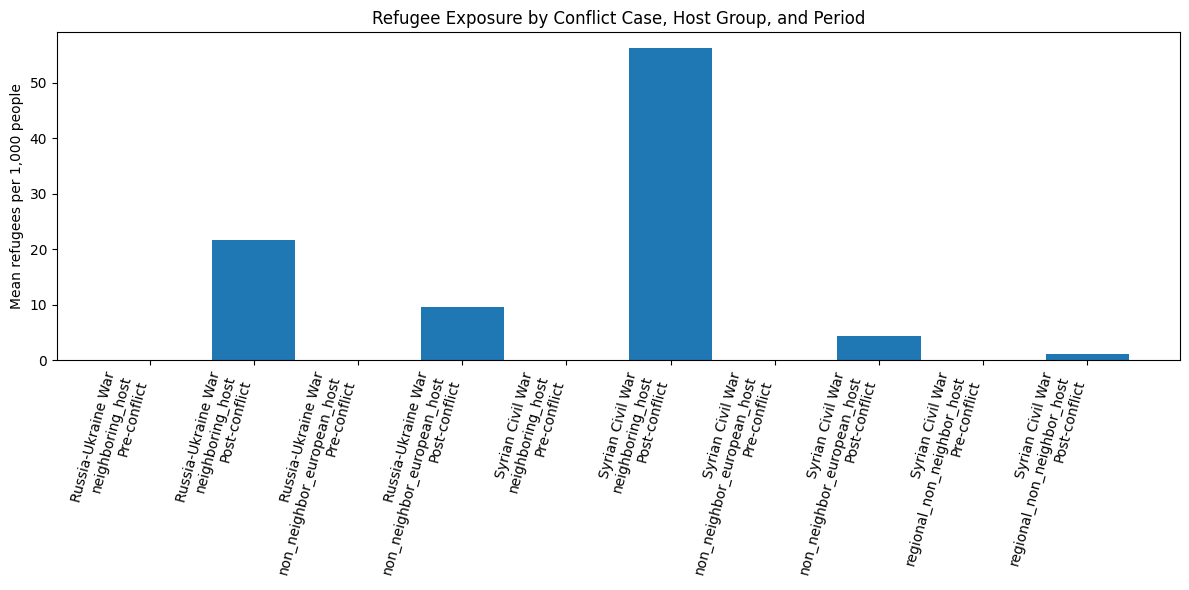

In [6]:
plot_data = group_summary.copy()
plot_data['period'] = plot_data['post_conflict'].map({0: 'Pre-conflict', 1: 'Post-conflict'})
plot_data['label'] = plot_data['conflict_case'] + '\n' + plot_data['host_group'] + '\n' + plot_data['period']

plt.figure(figsize=(12, 6))
plt.bar(plot_data['label'], plot_data['mean_refugees_per_1000'])
plt.xticks(rotation=75, ha='right')
plt.ylabel('Mean refugees per 1,000 people')
plt.title('Refugee Exposure by Conflict Case, Host Group, and Period')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'final_refugee_exposure_by_group.png', dpi=300)
plt.show()

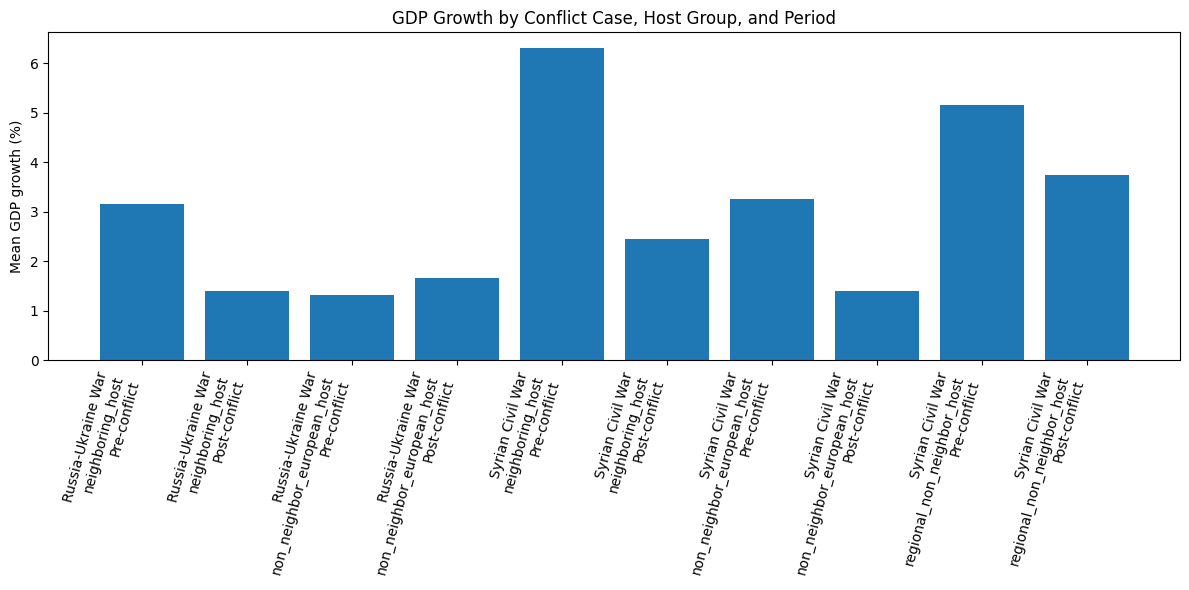

In [7]:
plt.figure(figsize=(12, 6))
plt.bar(plot_data['label'], plot_data['mean_gdp_growth'])
plt.xticks(rotation=75, ha='right')
plt.ylabel('Mean GDP growth (%)')
plt.title('GDP Growth by Conflict Case, Host Group, and Period')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'final_gdp_growth_by_group.png', dpi=300)
plt.show()

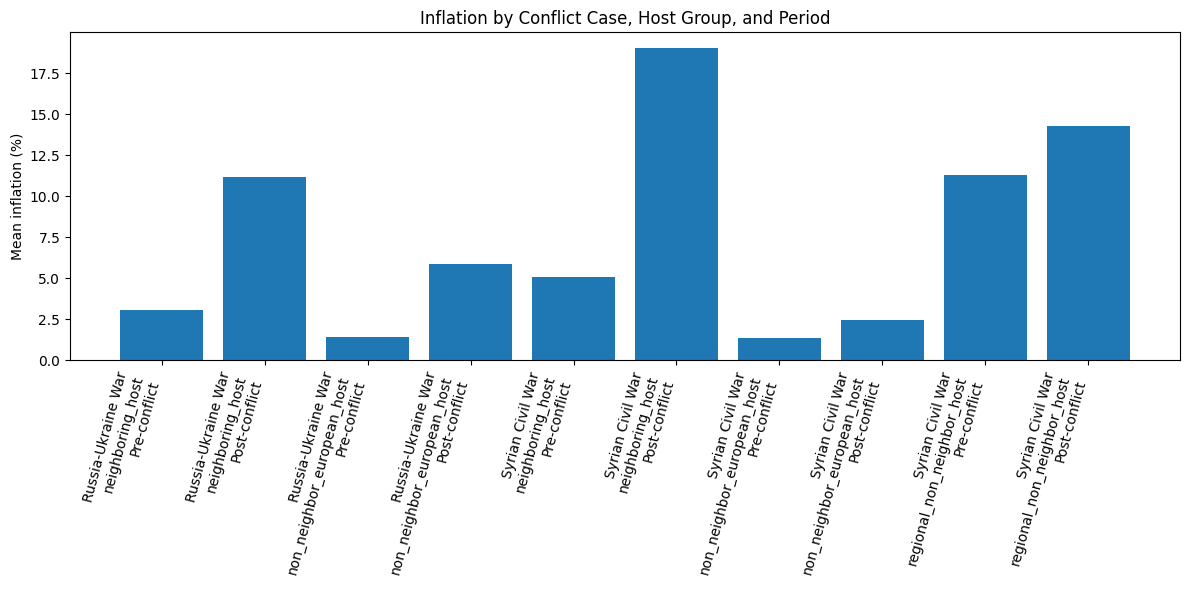

In [8]:
plt.figure(figsize=(12, 6))
plt.bar(plot_data['label'], plot_data['mean_inflation'])
plt.xticks(rotation=75, ha='right')
plt.ylabel('Mean inflation (%)')
plt.title('Inflation by Conflict Case, Host Group, and Period')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'final_inflation_by_group.png', dpi=300)
plt.show()

### Descriptive Interpretation

The descriptive tables suggest that refugee exposure increased much more strongly among neighboring host countries after conflict onset. This pattern is especially visible for the Syrian Civil War and is also present in the Russia–Ukraine case.

GDP growth is generally lower in post-conflict periods for most groups, but this cannot be attributed only to refugee exposure because the same years include other macroeconomic shocks. Inflation increases in the post-conflict period, especially for neighboring hosts, but this result also needs caution because inflation is affected by broader global and domestic conditions.

## 4. Hypothesis Tests

The tests below are exploratory.

- Spearman correlation checks whether higher refugee exposure is associated with macroeconomic outcomes.
- Mann–Whitney U tests compare neighboring host countries with other host groups during post-conflict periods.

These tests do not prove causality.

In [9]:
test_rows = []

for scope in ['All'] + sorted(df['conflict_case'].dropna().unique().tolist()):
    sub = df if scope == 'All' else df[df['conflict_case'] == scope]

    for y in ['gdp_growth', 'inflation', 'unemployment']:
        tmp = sub[['refugees_per_1000', y]].dropna()
        if len(tmp) >= 3:
            statistic, p_value = spearmanr(tmp['refugees_per_1000'], tmp[y])
        else:
            statistic, p_value = np.nan, np.nan
        test_rows.append({
            'scope': scope,
            'test': 'Spearman correlation',
            'comparison': 'refugees_per_1000 vs outcome',
            'outcome': y,
            'n': len(tmp),
            'statistic': statistic,
            'p_value': p_value,
            'interpretation': 'association, not causation'
        })

    post = sub[sub['post_conflict'] == 1]
    neighboring = post[post['host_group'] == 'neighboring_host']
    other = post[post['host_group'] != 'neighboring_host']

    for y in ['refugees_per_1000', 'gdp_growth', 'inflation']:
        a = neighboring[y].dropna()
        b = other[y].dropna()
        if len(a) > 0 and len(b) > 0:
            statistic, p_value = mannwhitneyu(a, b, alternative='two-sided')
        else:
            statistic, p_value = np.nan, np.nan
        test_rows.append({
            'scope': scope,
            'test': 'Mann-Whitney U',
            'comparison': 'post-conflict neighboring hosts vs other host groups',
            'outcome': y,
            'n': len(a) + len(b),
            'statistic': statistic,
            'p_value': p_value,
            'interpretation': 'group difference, not causation'
        })

hypothesis_tests = pd.DataFrame(test_rows)
hypothesis_tests.to_csv(TABLE_DIR / 'final_hypothesis_tests.csv', index=False)
hypothesis_tests

,scope,test,comparison,outcome,n,statistic,p_value,interpretation
0,All,Spearman correlation,refugees_per_1000 vs outcome,gdp_growth,329,-0.097212,7.828459e-02,"association, not causation"
1,All,Spearman correlation,refugees_per_1000 vs outcome,inflation,330,0.276892,3.201303e-07,"association, not causation"
2,All,Spearman correlation,refugees_per_1000 vs outcome,unemployment,329,0.073386,1.842345e-01,"association, not causation"
3,All,Mann-Whitney U,post-conflict neighboring hosts vs other host ...,refugees_per_1000,165,5582.000000,1.502749e-13,"group difference, not causation"
4,All,Mann-Whitney U,post-conflict neighboring hosts vs other host ...,gdp_growth,164,3712.000000,1.611189e-01,"group difference, not causation"
5,All,Mann-Whitney U,post-conflict neighboring hosts vs other host ...,inflation,165,4095.000000,1.266539e-02,"group difference, not causation"
6,Russia-Ukraine War,Spearman correlation,refugees_per_1000 vs outcome,gdp_growth,195,-0.123280,8.597841e-02,"association, not causation"
7,Russia-Ukraine War,Spearman correlation,refugees_per_1000 vs outcome,inflation,195,0.294599,2.907930e-05,"association, not causation"
8,Russia-Ukraine War,Spearman correlation,refugees_per_1000 vs outcome,unemployment,195,-0.246724,5.069173e-04,"association, not causation"
9,Russia-Ukraine War,Mann-Whitney U,post-conflict neighboring hosts vs other host ...,refugees_per_1000,39,269.000000,1.062565e-02,"group difference, not causation"


### Hypothesis Test Interpretation

The strongest and most consistent result is that neighboring host countries have significantly higher refugee exposure than non-neighbor host groups during post-conflict years. This supports the project’s basic spillover mechanism.

The macroeconomic results are weaker. Refugee exposure has a positive association with inflation in the combined dataset, while the GDP growth relationship is negative but weaker. These findings should be interpreted as exploratory evidence, not as proof that refugee inflows directly caused changes in GDP growth or inflation.

## 5. Machine Learning Analysis

The machine learning task predicts `gdp_growth` using refugee exposure, conflict timing, host-country group, conflict case, and macroeconomic variables.

Models used:

1. Linear Regression
2. Decision Tree Regressor

The same models are used because they are interpretable and appropriate for a course project checkpoint.

In [10]:
target = 'gdp_growth'

numeric_features = [
    'post_conflict',
    'refugees_per_1000',
    'log_refugee_stock',
    'inflation',
    'unemployment',
    'trade_pct_gdp',
    'current_account_pct_gdp',
    'year'
]

categorical_features = [
    'conflict_case',
    'host_name',
    'host_group'
]

ml_columns = [target] + numeric_features + categorical_features
ml_df = df[ml_columns].dropna().copy()

X = ml_df[numeric_features + categorical_features]
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

def evaluate_model(model_name, y_true, y_pred):
    return {
        'model': model_name,
        'target': target,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)
linear_results = evaluate_model('Linear Regression', y_test, linear_predictions)

tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(max_depth=4, min_samples_leaf=5, random_state=42))
])

tree_model.fit(X_train, y_train)
tree_predictions = tree_model.predict(X_test)
tree_results = evaluate_model('Decision Tree Regressor', y_test, tree_predictions)

ml_results = pd.DataFrame([linear_results, tree_results])
ml_results.to_csv(TABLE_DIR / 'final_ml_results.csv', index=False)

print('ML dataset shape:', ml_df.shape)
ml_results

ML dataset shape: (329, 12)


,model,target,MAE,RMSE,R2
0,Linear Regression,gdp_growth,2.018344,3.129857,0.202533
1,Decision Tree Regressor,gdp_growth,2.165246,3.185891,0.173723


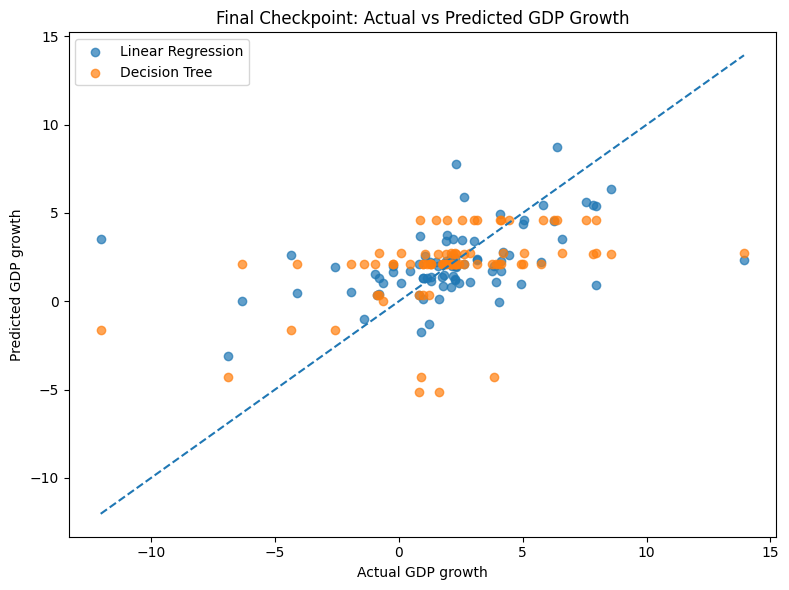

In [11]:
prediction_df = pd.DataFrame({
    'actual_gdp_growth': y_test.values,
    'linear_prediction': linear_predictions,
    'tree_prediction': tree_predictions
})

plt.figure(figsize=(8, 6))
plt.scatter(prediction_df['actual_gdp_growth'], prediction_df['linear_prediction'], alpha=0.7, label='Linear Regression')
plt.scatter(prediction_df['actual_gdp_growth'], prediction_df['tree_prediction'], alpha=0.7, label='Decision Tree')

min_value = min(
    prediction_df['actual_gdp_growth'].min(),
    prediction_df['linear_prediction'].min(),
    prediction_df['tree_prediction'].min()
)
max_value = max(
    prediction_df['actual_gdp_growth'].max(),
    prediction_df['linear_prediction'].max(),
    prediction_df['tree_prediction'].max()
)
plt.plot([min_value, max_value], [min_value, max_value], linestyle='--')
plt.xlabel('Actual GDP growth')
plt.ylabel('Predicted GDP growth')
plt.title('Final Checkpoint: Actual vs Predicted GDP Growth')
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'final_actual_vs_predicted_gdp_growth.png', dpi=300)
plt.show()

In [12]:
feature_names = tree_model.named_steps['preprocessor'].get_feature_names_out()
tree_importances = tree_model.named_steps['model'].feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': tree_importances
}).sort_values('importance', ascending=False)

importance_df.to_csv(TABLE_DIR / 'final_tree_feature_importance.csv', index=False)
importance_df.head(15)

,feature,importance
7,num__year,0.313449
1,num__refugees_per_1000,0.255341
26,cat__host_group_non_neighbor_european_host,0.198152
5,num__trade_pct_gdp,0.169381
4,num__unemployment,0.063676
0,num__post_conflict,0.000000
16,cat__host_name_Jordan,0.000000
25,cat__host_name_Turkey,0.000000
24,cat__host_name_Sweden,0.000000
23,cat__host_name_Spain,0.000000


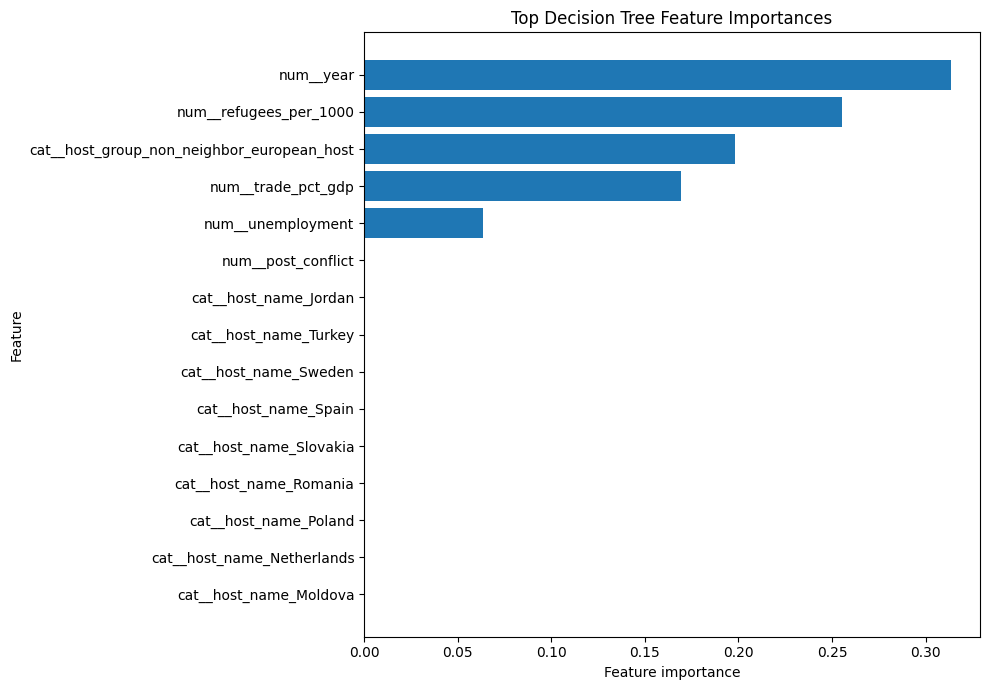

In [13]:
top_importance = importance_df.head(15).copy()

plt.figure(figsize=(10, 7))
plt.barh(top_importance['feature'], top_importance['importance'])
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.title('Top Decision Tree Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'final_tree_feature_importance.png', dpi=300)
plt.show()

### Machine Learning Interpretation

Linear Regression performs slightly better than the Decision Tree Regressor on the current train-test split. The positive R² value means the model captures some signal, but the score is not strong enough for confident prediction.

This is acceptable for the project because the goal is not to build a high-accuracy economic forecasting system. The goal is to test whether conflict and refugee exposure variables contain useful information when combined with macroeconomic indicators.

A methodological weakness remains: using contemporaneous macroeconomic variables such as inflation and unemployment to predict GDP growth can create an explanatory model rather than a clean forecasting model. This should be stated clearly in the report or presentation.

## 6. Ethics, Bias, and Limitations

This project uses public, country-year level datasets. It does not use individual-level refugee records, personal identifiers, or private information. This reduces privacy risk.

Important limitations:

- The analysis is not causal. It cannot prove that refugee inflows caused macroeconomic changes.
- Conflict years overlap with other shocks, including global inflation, COVID-19 recovery, domestic policy changes, and energy market disruptions.
- Country-level indicators hide local differences inside each host country.
- Refugee data may reflect registration and reporting systems, not the exact number of displaced people.
- Comparing Syria and Ukraine is useful but imperfect because the conflicts differ in geography, timing, international response, and host-country capacity.

Ethical framing matters. Refugees should not be presented as the cause of economic problems. The project should describe refugee exposure as one possible channel of wartime spillover, while recognizing that displaced people are themselves affected by conflict.

## 7. Final Checkpoint Conclusion

The Final version of the project is in a defensible state.

Main findings:

1. Neighboring host countries generally receive much higher refugee exposure after conflict onset.
2. Inflation tends to be higher in post-conflict periods, especially for neighboring host groups, but this is not causal evidence.
3. GDP growth often declines after conflict onset, but the relationship is weaker and affected by many other economic factors.
4. The machine learning models show limited but non-zero predictive value for GDP growth.
5. The project’s strongest contribution is not causal identification; it is the construction of a combined conflict-host panel and a clear exploratory comparison between neighboring and non-neighbor host countries.

For a final presentation, the safest claim is:

> The project finds evidence of measurable economic spillover patterns around major conflicts, especially through refugee exposure and inflation differences, but the results should be interpreted as exploratory associations rather than causal effects.